# Clasificación Automática de Noticias Mediante Técnicas de Machine Learning

**Materia:** Inteligencia Artificial 2026-1                                     
**Integrantes:** Martinez Uribe Juan Sebastian - Mosquera Molina Sergio Andres - Vergara Vergara Eduardo Enrique                                              
**Fecha de entrega:** 22 de Mayo de 2026  
**Dataset:** [News Category Classification Dataset — Kaggle](https://www.kaggle.com/datasets/bornaetminan/news-category-classification-dataset)

---
# BLOQUE I — Descripción del problema e inspección del conjunto de datos

## 1. Descripción del problema

### 1.1 Contexto y motivación

El crecimiento exponencial del contenido digital ha transformado la forma
en que se produce y consume información periodística. Según el informe
Digital News Report 2023 del Reuters Institute, más del 60% de los usuarios
accede a noticias a través de plataformas digitales, donde los sistemas de
recomendación y búsqueda dependen directamente de una categorización
precisa del contenido [1]. En este contexto, la clasificación manual de
artículos resulta inviable a escala: un portal de noticias de mediano tamaño
puede publicar cientos de artículos diarios en múltiples secciones temáticas,
lo que exige criterios consistentes, personal especializado y tiempos de
procesamiento incompatibles con la inmediatez del periodismo digital.

El Procesamiento de Lenguaje Natural (NLP) y el aprendizaje automático
ofrecen una solución viable a este problema. Trabajos como el de Zhang et al.
(2015) demostraron que modelos de clasificación de texto supervisados pueden
alcanzar niveles de precisión comparables a los anotadores humanos en tareas
de categorización de noticias [2], abriendo la puerta a la automatización
escalable de estos procesos.

### 1.2 Descripción del problema de clasificación

El problema abordado en este trabajo corresponde a una tarea de
**clasificación multiclase supervisada** sobre datos textuales. Dado un
artículo periodístico representado por su titular (`headline`) y descripción
corta (`short_description`), el objetivo es aprender una función
f: X → Y, donde X es el espacio de representaciones vectoriales del texto
e Y = {categoría₁, categoría₂, ..., categoríaₙ} es el conjunto de
etiquetas temáticas posibles.

Este problema presenta varios retos técnicos propios del dominio:

- **Alta dimensionalidad:** la representación vectorial del vocabulario genera
  espacios de miles de features, lo que requiere técnicas de selección de
  características.
- **Desbalance de clases:** algunas categorías concentran significativamente
  más artículos que otras, lo que puede sesgar el aprendizaje del modelo.
- **Ambigüedad semántica:** categorías como *Politics* y *Government*, o
  *Wellness* y *Healthy Living*, comparten vocabulario similar, dificultando
  la separación de las fronteras de decisión.

### 1.3 Objetivo del trabajo

Desarrollar un sistema de clasificación automática de noticias basado en
técnicas de aprendizaje supervisado, que a partir del contenido textual de
un artículo (titular y descripción corta) sea capaz de predecir su categoría
temática, evaluando y comparando el desempeño de múltiples algoritmos de
Machine Learning con el fin de determinar el modelo más efectivo para la
organización automatizada de contenido periodístico digital.

### 1.4 Objetivos específicos

- Analizar las características textuales del dataset e identificar patrones léxicos por categoría.
- Preprocesar los datos mediante técnicas de NLP (limpieza, normalización, vectorización TF-IDF) y selección de características con Chi-squared.
- Implementar y ajustar con `GridSearchCV` los siguientes modelos: Regresión Logística, Árbol de Decisión, Random Forest, MLP y DNN.
- Evaluar el desempeño con métricas de clasificación (accuracy, precision, recall, F1-score) y matrices de confusión.
- Comparar los modelos y determinar el más adecuado para la tarea de clasificación de noticias.



### 1.5 Variables del dataset

| Variable | Tipo | Rol | Descripción |
|---|---|---|---|
| `category` | Categórica | **Variable objetivo (y)** | Categoría temática de la noticia |
| `headline` | Texto | Feature principal | Titular del artículo |
| `short_description` | Texto | Feature principal | Resumen corto de la noticia |
| `authors` | Texto | Informativa | Autor(es) del artículo |
| `date` | Fecha | Informativa | Fecha de publicación |
| `link` | Texto | Informativa | URL original del artículo |


## 2. Librerías e Inspección del conjunto de datos

### 2.1 Librerías utilizadas

| Librería | Módulo | Propósito |
|---|---|---|
| `pandas` | — | Manipulación y análisis de datos estructurados |
| `numpy` | — | Operaciones numéricas y manejo de arreglos |
| `re` | — | Limpieza de texto mediante expresiones regulares |
| `matplotlib` | `pyplot` | Generación de gráficas y visualizaciones |
| `seaborn` | — | Visualizaciones estadísticas de alto nivel |
| `wordcloud` | `WordCloud` | Generación de nubes de palabras por categoría |
| `nltk` | `word_tokenize` | Tokenización de texto en palabras individuales |
| `nltk` | `stopwords` | Corpus de palabras vacías en inglés para su eliminación |
| `nltk` | `WordNetLemmatizer` | Lematización: reducción de palabras a su forma base |




In [4]:
# ── Importaciones generales ──────────────────────────────────────────────────
# standard
import pandas as pd
import numpy as np
from pandas.plotting import scatter_matrix
import re

# plots
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# string functions
import string

# NLTK
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk import WordNetLemmatizer
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [6]:
# ── Carga del dataset ────────────────────────────────────────────────────────

ARCHIVO = r"C:\Users\ACER-A315-59\OneDrive\Desktop\Proyecto final IA\Taller ML\Taller ML\archive\news_category_clean.csv"   

try:
    df = pd.read_csv(ARCHIVO)
    print(f"\n Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")
except FileNotFoundError:
    print(f"\n  Archivo '{ARCHIVO}' no encontrado.")
    print("   Descarga el dataset de Kaggle y colócalo en esta carpeta.")
    print("   Luego cambia la variable ARCHIVO con el nombre correcto.")
    exit()

from IPython.display import display
display(df.head(10))



 Dataset cargado: 206641 registros, 10 columnas


,category,authors,date,clean_headline,clean_description,year,month,headline_char_count,headline_word_count,avg_word_length
0,U.S. NEWS,"Carla K. Johnson, AP",2022-09-23,over million americans roll up sleeves for omi...,health experts said it is too early to predict...,2022,9,73,10,7.300000
1,U.S. NEWS,Mary Papenfuss,2022-09-23,american airlines flyer charged banned for lif...,he was subdued by passengers and crew when he ...,2022,9,88,13,6.769231
2,COMEDY,Elyse Wanshel,2022-09-23,of the funniest tweets about cats and dogs thi...,until you have a dog you dont understand what ...,2022,9,57,11,5.181818
3,PARENTING,Caroline Bologna,2022-09-23,the funniest tweets from parents this week sept,accidentally put grownup toothpaste on my todd...,2022,9,47,8,5.875000
4,U.S. NEWS,Nina Golgowski,2022-09-22,woman who called cops on black birdwatcher los...,amy cooper accused investment firm franklin te...,2022,9,75,11,6.818182
5,U.S. NEWS,Unknown,2022-09-22,cleaner was dead in belk bathroom for days bef...,the yearold woman was seen working at the sout...,2022,9,67,12,5.583333
6,U.S. NEWS,Elyse Wanshel,2022-09-22,reporter gets adorable surprise from her boyfr...,whos that behind you an anchor for new yorks p...,2022,9,67,11,6.090909
7,WORLD NEWS,"DÁNICA COTO, AP",2022-09-22,puerto ricans desperate for water after hurric...,more than half a million people remained witho...,2022,9,64,9,7.111111
8,CULTURE & ARTS,Marina Fang,2022-09-22,how a new documentary captures the complexity ...,in mija director isabel castro combined music ...,2022,9,76,13,5.846154
9,WORLD NEWS,"Aamer Madhani, AP",2022-09-21,biden at un to call russian war an affront to ...,white house officials say the crux of the pres...,2022,9,59,12,4.916667


In [9]:
# ── Tipos de datos e información general ────────────────────────────────────
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 206641 entries, 0 to 206640
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   category             206641 non-null  str    
 1   authors              206641 non-null  str    
 2   date                 206641 non-null  str    
 3   clean_headline       206641 non-null  str    
 4   clean_description    186857 non-null  str    
 5   year                 206641 non-null  int64  
 6   month                206641 non-null  int64  
 7   headline_char_count  206641 non-null  int64  
 8   headline_word_count  206641 non-null  int64  
 9   avg_word_length      206641 non-null  float64
dtypes: float64(1), int64(4), str(5)
memory usage: 15.8 MB


None

In [12]:
# ── Valores nulos ────────────────────────────────────────────────────────────
from IPython.display import display

nulos = df.isnull().sum()
df_nulos = pd.DataFrame({'Columna': nulos.index, 'Valores Nulos': nulos.values})



display(df_nulos.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid #D3D3D3'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('border', '1px solid #D3D3D3'), ('padding', '10px')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', "#000000")]}
]))

,Columna,Valores Nulos
0,category,0
1,authors,0
2,date,0
3,clean_headline,0
4,clean_description,19784
5,year,0
6,month,0
7,headline_char_count,0
8,headline_word_count,0
9,avg_word_length,0


In [7]:
# ── Registros duplicados ─────────────────────────────────────────────────────
print(f'Registros duplicados: {df.duplicated().sum()}')

Registros duplicados: 0


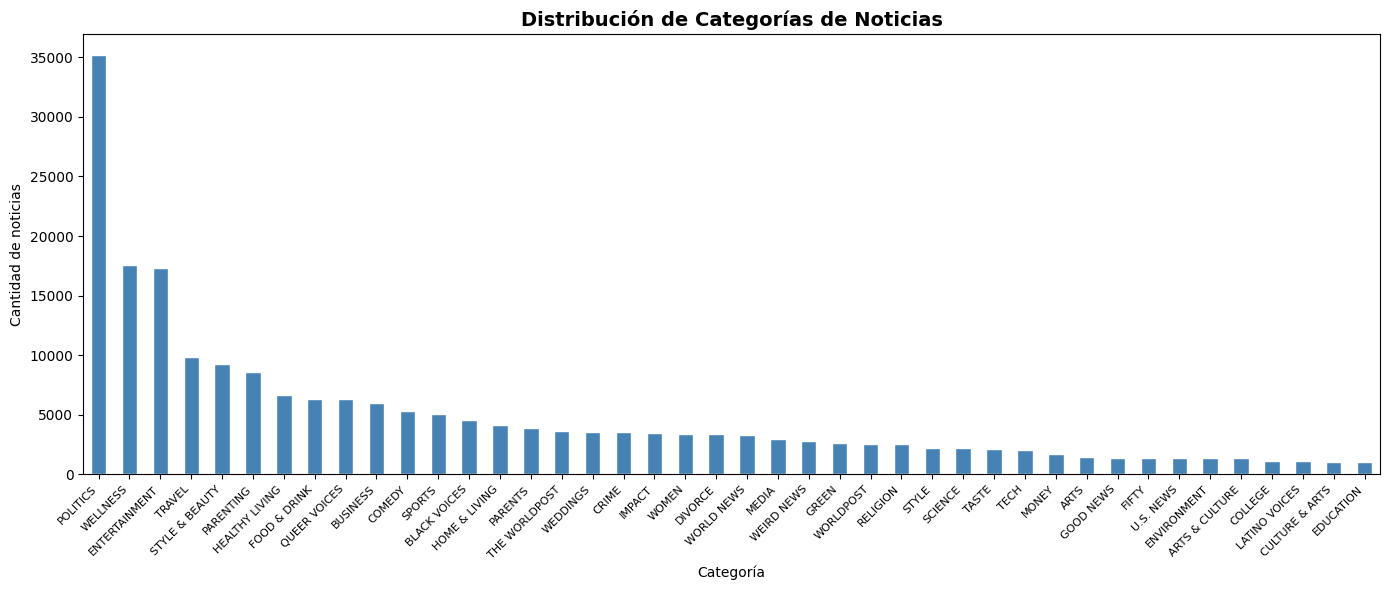

In [6]:
# ── GRÁFICA 2: barras  ─────────────────────────────────────
plt.figure(figsize=(14, 6))
conteo.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribución de Categorías de Noticias', fontsize=14, fontweight='bold')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de noticias')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('distribucion_categorias_barras.png', dpi=150)
plt.show()


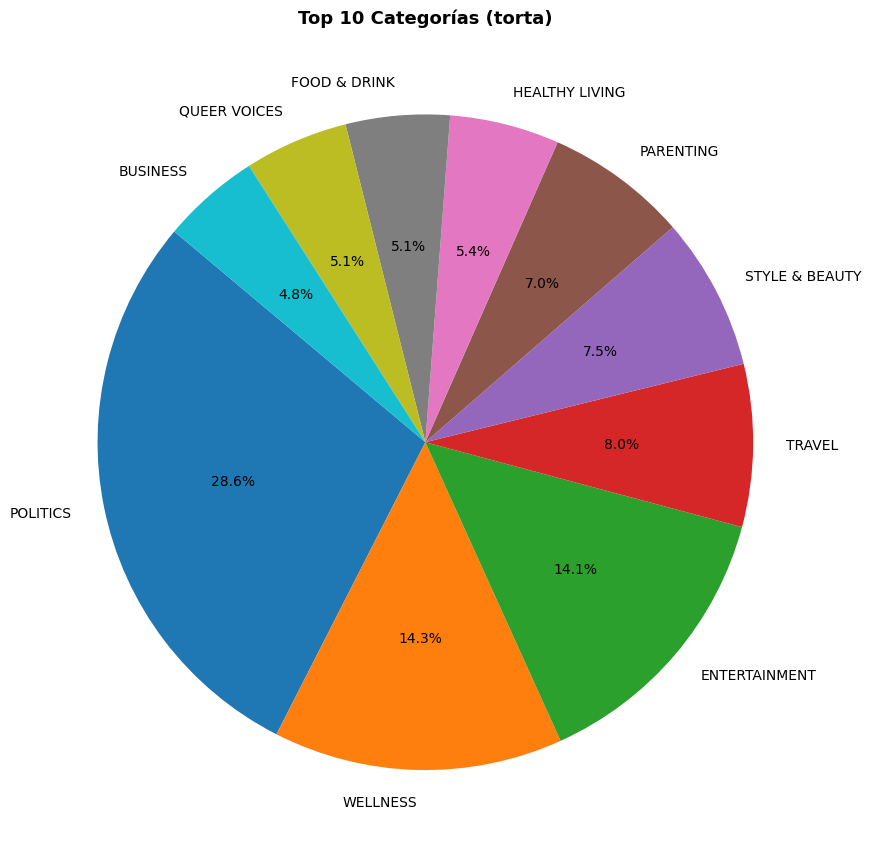

In [8]:
# ── GRÁFICA 3: Torta (top 10 para que sea legible) ────────
top10 = conteo.head(10)
plt.figure(figsize=(9, 9))
plt.pie(
top10.values,
        labels=top10.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('tab10')
    )
plt.title('Top 10 Categorías (torta)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_categorias_torta.png', dpi=150)
plt.show()

In [ ]:
# ── GRÁFICA 4:  Matriz de correlación 
COLUMNA_OBJETIVO = 'category'


import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import TfidfVectorize

# ── Parámetros generales ──────────────────────────────────────
TOP_CATEGORIAS = 15   # categorías más frecuentes a mostrar
TOP_PALABRAS   = 20   # palabras más importantes para la matriz de términos

# Filtrar solo las TOP_CATEGORIAS más frecuentes (para legibilidad)
cats_top = df[COLUMNA_OBJETIVO].value_counts().head(TOP_CATEGORIAS).index.tolist()
df_top   = df[df[COLUMNA_OBJETIVO].isin(cats_top)].copy()

print("\n[6A] Calculando matriz de similitud coseno entre categorías...")

# Vectorizador TF-IDF sobre todo el corpus filtrado
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
# Usar una columna de texto que realmente exista en este punto del notebook
if 'text' in df_top.columns:
    texto_entrada = df_top['text'].fillna('')
elif 'text_raw' in df_top.columns:
    texto_entrada = df_top['text_raw'].fillna('')
else:
    texto_entrada = (
        df_top.get('clean_headline', '').fillna('') + ' ' +
        df_top.get('clean_description', '').fillna('')
    ).str.strip()

X_tfidf = tfidf_vec.fit_transform(texto_entrada)


[6A] Calculando matriz de similitud coseno entre categorías...


---
## 3. Análisis Exploratorio de Datos (EDA)

In [14]:
# ── Preparación: columna de texto combinado ──────────────────────────────────
# Combinamos headline + short_description como texto de entrada principal
df['text_raw'] = df['headline'].fillna('') + ' ' + df['short_description'].fillna('')
df['year'] = pd.to_datetime(df['date']).dt.year
df['text_length'] = df['text_raw'].str.split().str.len()

print('Estadísticas de longitud de texto:')
print(df['text_length'].describe())

Estadísticas de longitud de texto:


,count,mean,std,min,25%,50%,75%,max
text_length,206641.00,28.78,13.41,1.00,20.00,28.00,35.00,238.00


In [ ]:
# ── GRÁFICA 3: Longitud de texto por categoría (top 10) ─────────────────────
top_cats = cat_counts.head(10).index
df_top = df[df['category'].isin(top_cats)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='text_length', y='category', palette='Set2',
            order=top_cats)
plt.title('Distribución de longitud de texto por categoría (top 10)', fontsize=13)
plt.xlabel('Número de palabras (headline + descripción)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

> **[ANALIZAR]** ¿Existen diferencias significativas en la longitud de texto entre categorías? ¿Alguna categoría tiene textos notablemente más cortos o más largos? ¿Qué implica esto para la vectorización?

In [ ]:
# ── GRÁFICA 4: Evolución temporal de categorías ──────────────────────────────
df_time = df[df['category'].isin(top_cats)].groupby(
    ['year', 'category']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))
for cat in top_cats:
    data = df_time[df_time['category'] == cat]
    plt.plot(data['year'], data['count'], marker='o', label=cat)

plt.title('Evolución temporal del número de noticias por categoría', fontsize=13)
plt.xlabel('Año')
plt.ylabel('Número de noticias')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

> **[ANALIZAR]** ¿Hay categorías que crecieron o decayeron con el tiempo? ¿Podría el año de publicación influir en el vocabulario usado? Esto es relevante para entender posibles sesgos del modelo.

In [ ]:
# ── GRÁFICA 5: Test Chi-squared de independencia (año vs categoría) ──────────
from scipy.stats import chi2_contingency

tabla_contingencia = pd.crosstab(df['year'], df['category'])
chi2_stat, p_valor, dof, _ = chi2_contingency(tabla_contingencia)

print(f'Estadístico Chi² = {chi2_stat:.2f}')
print(f'Grados de libertad = {dof}')
print(f'p-valor = {p_valor:.6f}')
print()
if p_valor < 0.05:
    print('Conclusión: existe una DEPENDENCIA estadísticamente significativa')
    print('entre el año de publicación y la categoría de la noticia (p < 0.05).')
else:
    print('Conclusión: no se rechaza la hipótesis de independencia (p >= 0.05).')

> **[ANALIZAR]** Interpreta el resultado del test Chi-squared. Si p < 0.05, la distribución de categorías varía significativamente entre años, lo que indica un sesgo temporal en el dataset.

In [ ]:
# ── GRÁFICA 6: WordCloud general ────────────────────────────────────────────
from wordcloud import WordCloud

texto_total = ' '.join(df['text_raw'].dropna().values)
wc = WordCloud(width=900, height=400, background_color='white',
               colormap='viridis', max_words=150).generate(texto_total)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras — Todas las categorías (texto sin preprocesar)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── GRÁFICA 7: WordCloud por categoría (4 ejemplos) ─────────────────────────
categorias_ejemplo = ['POLITICS', 'SPORTS', 'ENTERTAINMENT', 'TECH']
# Ajusta los nombres según las categorías reales de tu dataset

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, cat in enumerate(categorias_ejemplo):
    if cat in df['category'].values:
        texto_cat = ' '.join(df[df['category'] == cat]['text_raw'].dropna().values)
        wc_cat = WordCloud(width=600, height=300, background_color='white',
                           max_words=80).generate(texto_cat)
        axes[i].imshow(wc_cat, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'Categoría: {cat}', fontsize=11, fontweight='bold')

plt.suptitle('Nubes de palabras por categoría (texto sin preprocesar)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **[ANALIZAR]** Compara el vocabulario de las WordClouds entre categorías: ¿qué palabras son discriminativas de cada una? ¿Hay palabras comunes entre categorías que podrían dificultar la clasificación? Esto justifica la eliminación de stopwords en el preprocesamiento.

---
# BLOQUE II — Diseño de experimentos y recolección de resultados

## 4. Preprocesamiento de datos

### 4.1 Justificación de las operaciones de preprocesamiento

> **[REDACTAR]** Basándote en el EDA anterior, justifica cada paso de preprocesamiento:
> - La presencia de URLs y caracteres especiales (observados en el EDA) → justifica limpieza con regex.
> - Las stopwords dominantes en las WordClouds → justifica su eliminación.
> - La variabilidad morfológica de las palabras → justifica la lematización.
> - El alto número de features TF-IDF → justifica la selección con Chi-squared.

In [ ]:
# ── Instalación y descarga de recursos NLTK ──────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    """Limpia y normaliza texto para clasificación."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # eliminar URLs
    text = re.sub(r'[^a-z\s]', ' ', text)               # solo letras
    text = re.sub(r'\s+', ' ', text).strip()             # espacios múltiples
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens   # lematización
              if t not in stop_words and len(t) > 2]     # sin stopwords ni letras sueltas
    return ' '.join(tokens)

print('Función de preprocesamiento definida.')
print('Ejemplo:')
ejemplo = "Trump's tweets about healthcare policy hit 1M views — https://example.com"
print(f'  Original : {ejemplo}')
print(f'  Procesado: {preprocess_text(ejemplo)}')

In [ ]:
# ── Aplicar preprocesamiento ─────────────────────────────────────────────────
print('Preprocesando textos... (puede tardar unos minutos)')
df['text'] = df['text_raw'].apply(preprocess_text)
df['text_length_clean'] = df['text'].str.split().str.len()
print('Preprocesamiento completado.')
df[['text_raw', 'text']].head(3)

In [ ]:
# ── GRÁFICA 8: Longitud de texto antes y después del preprocesamiento ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Longitud de texto — ANTES del preprocesamiento')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['text_length_clean'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Longitud de texto — DESPUÉS del preprocesamiento')
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Efecto del preprocesamiento en la longitud del texto', fontsize=13)
plt.tight_layout()
plt.show()

reduccion = (1 - df['text_length_clean'].mean() / df['text_length'].mean()) * 100
print(f'Reducción promedio de tokens: {reduccion:.1f}%')

> **[ANALIZAR]** Comenta la reducción de tokens observada. ¿Es razonable? ¿Qué información se eliminó y por qué es correcto hacerlo?

In [ ]:
# ── División del dataset (estratificada) ─────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df['text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]:,} muestras')
print(f'Conjunto de prueba:        {X_test.shape[0]:,} muestras')
print(f'Clases únicas: {y.nunique()}')

In [ ]:
# ── Vectorización TF-IDF ─────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),   # unigramas y bigramas
    sublinear_tf=True,    # aplica 1 + log(tf) para suavizar frecuencias
    min_df=3              # ignora términos que aparecen en menos de 3 documentos
)

X_train_tfidf = vectorizer.fit_transform(X_train)  # ajuste SOLO en train
X_test_tfidf  = vectorizer.transform(X_test)

print(f'Dimensión de la matriz TF-IDF (train): {X_train_tfidf.shape}')
print(f'Dimensión de la matriz TF-IDF (test):  {X_test_tfidf.shape}')

### 4.2 Selección de características con Chi-squared

> **[REDACTAR]** Explica qué es el test Chi-squared en el contexto de selección de características: mide la independencia estadística entre cada término (feature) y la variable de clase. Términos con alto Chi² son estadísticamente más relevantes para discriminar categorías.

In [ ]:
# ── Selección de características con Chi-squared ─────────────────────────────
from sklearn.feature_selection import SelectKBest, chi2

# Seleccionamos las k features con mayor score Chi²
k_features = 15000
selector = SelectKBest(chi2, k=k_features)

X_train_chi2 = selector.fit_transform(X_train_tfidf, y_train)
X_test_chi2  = selector.transform(X_test_tfidf)

print(f'Features antes de Chi²: {X_train_tfidf.shape[1]:,}')
print(f'Features después de Chi²: {X_train_chi2.shape[1]:,}')
print(f'Reducción: {(1 - k_features/X_train_tfidf.shape[1])*100:.1f}%')

In [ ]:
# ── GRÁFICA 9: Top 20 términos con mayor score Chi² ─────────────────────────
feature_names = vectorizer.get_feature_names_out()
chi2_scores = selector.scores_

top_n = 20
top_indices = chi2_scores.argsort()[-top_n:][::-1]
top_words = feature_names[top_indices]
top_scores = chi2_scores[top_indices]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_scores[::-1], color='steelblue', edgecolor='white')
plt.yticks(range(top_n), top_words[::-1])
plt.title(f'Top {top_n} términos con mayor score Chi² (todas las clases)', fontsize=13)
plt.xlabel('Score Chi²')
plt.tight_layout()
plt.show()

> **[ANALIZAR]** Interpreta cuáles son las palabras más discriminativas según Chi². ¿Tienen sentido semánticamente? ¿Reflejan bien las categorías del dataset?

---
## 5. Entrenamiento de modelos

> **[REDACTAR]** Explica la estrategia de experimentación: se usará `GridSearchCV` con validación cruzada de 5 folds para ajustar hiperparámetros. El scoring objetivo es `f1_macro` por tratarse de un problema multiclase con posible desbalance. Cada modelo se ajusta sobre el conjunto de entrenamiento y se evalúa sobre el conjunto de prueba independiente.

In [ ]:
# ── Importaciones para modelos y evaluación ──────────────────────────────────
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.pipeline import Pipeline
import time
import joblib

# Diccionario para guardar resultados de todos los modelos
resultados = {}

def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te):
    """Entrena con GridSearchCV, evalúa y guarda resultados."""
    print(f'\n{'='*55}')
    print(f'  Entrenando: {nombre}')
    print(f'{'='*55}')
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    t_total = time.time() - t0
    
    y_pred = modelo.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    reporte = classification_report(y_te, y_pred, output_dict=True)
    
    resultados[nombre] = {
        'modelo': modelo,
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_macro': reporte['macro avg']['f1-score'],
        'precision_macro': reporte['macro avg']['precision'],
        'recall_macro': reporte['macro avg']['recall'],
        'tiempo_s': t_total,
        'mejores_params': modelo.best_params_ if hasattr(modelo, 'best_params_') else {}
    }
    
    if hasattr(modelo, 'best_params_'):
        print(f'Mejores parámetros: {modelo.best_params_}')
    print(f'Accuracy:   {acc:.4f}')
    print(f'F1-macro:   {reporte["macro avg"]["f1-score"]:.4f}')
    print(f'Tiempo:     {t_total:.1f}s')
    return modelo

print('Funciones de evaluación listas.')

### 5.1 Regresión Logística

> **[REDACTAR]** Explica brevemente el modelo: clasificador lineal que estima probabilidades usando la función softmax para el caso multiclase (multinomial). El parámetro C controla la regularización (C pequeño = más regularización).

In [ ]:
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['saga'],
    'max_iter': [1000]
}

gs_lr = GridSearchCV(
    LogisticRegression(multi_class='multinomial', random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

evaluar_modelo('Regresión Logística', gs_lr,
               X_train_chi2, X_test_chi2, y_train, y_test)

# Guardar modelo
joblib.dump(gs_lr, 'modelo_lr.pkl')

> **[ANALIZAR]** ¿Cuál fue el mejor valor de C? ¿Qué indica esto sobre la regularización óptima para este dataset?

### 5.2 Árbol de Decisión

> **[REDACTAR]** Describe el modelo: estructura jerárquica de decisiones binarias basada en criterios de impureza (Gini o entropía). Propenso a sobreajuste cuando la profundidad no está limitada.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [10, 20, 30, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 10, 20]
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

evaluar_modelo('Árbol de Decisión', gs_dt,
               X_train_chi2, X_test_chi2, y_train, y_test)

joblib.dump(gs_dt, 'modelo_dt.pkl')

> **[ANALIZAR]** ¿Qué profundidad máxima resultó óptima? ¿Hay indicios de sobreajuste? Compara el score de entrenamiento vs prueba si es posible.

### 5.3 Random Forest

> **[REDACTAR]** Describe el modelo: ensamble de árboles de decisión entrenados con muestras bootstrap y selección aleatoria de features. Reduce la varianza respecto a un solo árbol mediante el promedio de predicciones.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [20, 30, None]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,                  # cv=3 por el alto costo computacional
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

evaluar_modelo('Random Forest', gs_rf,
               X_train_chi2, X_test_chi2, y_train, y_test)

joblib.dump(gs_rf, 'modelo_rf.pkl')

> **[ANALIZAR]** ¿Cuántos árboles y qué estrategia de selección de features resultaron óptimos? ¿Mejoró Random Forest respecto al árbol individual?

### 5.4 Red Neuronal — MLP (Multilayer Perceptron)

> **[REDACTAR]** Describe el modelo: red neuronal feedforward completamente conectada con una o más capas ocultas. Ajusta pesos mediante backpropagation con descenso de gradiente estocástico.

In [ ]:
from sklearn.neural_network import MLPClassifier

param_grid_mlp = {
    'hidden_layer_sizes': [(256,), (512,), (512, 256)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.0001],
    'alpha': [0.0001, 0.001]    # regularización L2
}

gs_mlp = GridSearchCV(
    MLPClassifier(max_iter=200, random_state=42, early_stopping=True),
    param_grid_mlp,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

evaluar_modelo('MLP', gs_mlp,
               X_train_chi2, X_test_chi2, y_train, y_test)

joblib.dump(gs_mlp, 'modelo_mlp.pkl')

> **[ANALIZAR]** ¿Qué arquitectura (capas y neuronas) resultó óptima? ¿Qué función de activación funcionó mejor y por qué podría ser así para clasificación de texto?

### 5.5 Red Neuronal Profunda — DNN (Deep Neural Network)

> **[REDACTAR]** Describe la diferencia con MLP: la DNN tiene más capas ocultas y usa técnicas de regularización como Dropout para evitar sobreajuste. Se implementa con TensorFlow/Keras para mayor flexibilidad arquitectónica.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder

# Codificar etiquetas de clase a enteros
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
n_classes   = len(le.classes_)

# Convertir matrices sparse a dense para Keras
X_train_dense = X_train_chi2.toarray()
X_test_dense  = X_test_chi2.toarray()

print(f'Clases: {n_classes}')
print(f'Input shape: {X_train_dense.shape}')

In [ ]:
# ── Arquitecturas DNN a comparar ─────────────────────────────────────────────
def crear_dnn(hidden_sizes, dropout_rate=0.3, lr=0.001):
    """Construye una DNN con las capas especificadas."""
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train_dense.shape[1],)))
    for units in hidden_sizes:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Dropout(dropout_rate))
    model.add(keras.layers.Dense(n_classes, activation='softmax'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

# ── Experimento 1: DNN con 2 capas ───────────────────────────────────────────
print('Entrenando DNN — Arquitectura 1: [512, 256]')
dnn1 = crear_dnn([512, 256], dropout_rate=0.3, lr=0.001)
history1 = dnn1.fit(
    X_train_dense, y_train_enc,
    epochs=30, batch_size=256,
    validation_split=0.15,
    callbacks=callbacks, verbose=1
)

In [ ]:
# ── Experimento 2: DNN con 3 capas ───────────────────────────────────────────
print('Entrenando DNN — Arquitectura 2: [512, 256, 128]')
dnn2 = crear_dnn([512, 256, 128], dropout_rate=0.4, lr=0.001)
history2 = dnn2.fit(
    X_train_dense, y_train_enc,
    epochs=30, batch_size=256,
    validation_split=0.15,
    callbacks=callbacks, verbose=1
)

In [ ]:
# ── GRÁFICA 10: Curvas de entrenamiento de la DNN ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pérdida
axes[0].plot(history2.history['loss'], label='Entrenamiento')
axes[0].plot(history2.history['val_loss'], label='Validación')
axes[0].set_title('Pérdida (loss) por época — DNN')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()

# Accuracy
axes[1].plot(history2.history['accuracy'], label='Entrenamiento')
axes[1].plot(history2.history['val_accuracy'], label='Validación')
axes[1].set_title('Accuracy por época — DNN')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Curvas de aprendizaje — DNN [512, 256, 128]', fontsize=13)
plt.tight_layout()
plt.show()

> **[ANALIZAR]** Observa las curvas de entrenamiento y validación: ¿convergen juntas? ¿Hay sobreajuste (val_loss sube mientras train_loss baja)? ¿Cuántas épocas tardó EarlyStopping en detener el entrenamiento?

In [ ]:
# ── Evaluar la mejor DNN ─────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score

# Seleccionar la mejor DNN (la que tenga mayor val_accuracy final)
best_dnn = dnn2  # ajustar según resultados

y_pred_dnn_enc = np.argmax(best_dnn.predict(X_test_dense), axis=1)
y_pred_dnn = le.inverse_transform(y_pred_dnn_enc)

reporte_dnn = classification_report(y_test, y_pred_dnn, output_dict=True)
resultados['DNN'] = {
    'modelo': best_dnn,
    'y_pred': y_pred_dnn,
    'accuracy': accuracy_score(y_test, y_pred_dnn),
    'f1_macro': reporte_dnn['macro avg']['f1-score'],
    'precision_macro': reporte_dnn['macro avg']['precision'],
    'recall_macro': reporte_dnn['macro avg']['recall'],
    'tiempo_s': 0,
    'mejores_params': {'arquitectura': '[512, 256, 128]', 'dropout': 0.4}
}

print(classification_report(y_test, y_pred_dnn))

---
## 6. Evaluación de modelos

> **[REDACTAR]** Explica qué mide cada métrica en el contexto de este problema:
> - **Accuracy:** proporción de predicciones correctas sobre el total.
> - **Precision (macro):** promedio de precisión por clase — qué tan fiables son las predicciones positivas.
> - **Recall (macro):** promedio de sensibilidad por clase — qué tan bien detecta cada categoría.
> - **F1-score (macro):** media armónica de precision y recall, equilibra ambos.

In [ ]:
# ── GRÁFICAS 11–15: Matrices de confusión por modelo ─────────────────────────
clases = sorted(y.unique())

modelos_a_evaluar = {
    'Regresión Logística': gs_lr.predict(X_test_chi2),
    'Árbol de Decisión':   gs_dt.predict(X_test_chi2),
    'Random Forest':       gs_rf.predict(X_test_chi2),
    'MLP':                 gs_mlp.predict(X_test_chi2),
    'DNN':                 y_pred_dnn
}

for nombre, y_pred in modelos_a_evaluar.items():
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    fig, ax = plt.subplots(figsize=(16, 13))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=True)
    ax.set_title(f'Matriz de confusión — {nombre}', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    print(f'\n--- {nombre} ---')
    print(classification_report(y_test, y_pred))
    print()

> **[ANALIZAR — por cada matriz de confusión]**
> - ¿Qué categorías clasifica mejor cada modelo?
> - ¿Qué pares de categorías se confunden con mayor frecuencia? ¿Por qué (similitud semántica)?
> - ¿Hay categorías con bajo recall consistente en todos los modelos?
> 
> Responde estas preguntas para CADA uno de los 5 modelos.

---
# BLOQUE III — Comparación de modelos y conclusiones

## 7. Comparación de modelos

> **[REDACTAR]** Introduce esta sección explicando el criterio de comparación: se seleccionó F1-macro como métrica principal por ser más robusta ante el desbalance de clases que el accuracy simple.

In [ ]:
# ── Tabla resumen de resultados ──────────────────────────────────────────────
df_resultados = pd.DataFrame([
    {
        'Modelo': nombre,
        'Accuracy': v['accuracy'],
        'F1-Macro': v['f1_macro'],
        'Precision-Macro': v['precision_macro'],
        'Recall-Macro': v['recall_macro'],
        'Tiempo (s)': round(v['tiempo_s'], 1),
        'Mejores parámetros': str(v['mejores_params'])
    }
    for nombre, v in resultados.items()
]).sort_values('F1-Macro', ascending=False).reset_index(drop=True)

print('Tabla comparativa de modelos:')
df_resultados.style.format({
    'Accuracy': '{:.4f}',
    'F1-Macro': '{:.4f}',
    'Precision-Macro': '{:.4f}',
    'Recall-Macro': '{:.4f}'
}).background_gradient(subset=['F1-Macro'], cmap='Greens')

In [ ]:
# ── GRÁFICA 16: Comparación de métricas por modelo ───────────────────────────
metricas = ['Accuracy', 'F1-Macro', 'Precision-Macro', 'Recall-Macro']
df_plot = df_resultados[['Modelo'] + metricas].set_index('Modelo')

ax = df_plot.plot(kind='bar', figsize=(13, 6), colormap='Set2',
                  edgecolor='white', width=0.75)
ax.set_title('Comparación de métricas de evaluación por modelo', fontsize=13)
ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
# ── GRÁFICA 17: F1-Macro vs Tiempo de entrenamiento ─────────────────────────
plt.figure(figsize=(9, 5))
for _, row in df_resultados.iterrows():
    plt.scatter(row['Tiempo (s)'], row['F1-Macro'], s=120, zorder=5)
    plt.annotate(row['Modelo'], (row['Tiempo (s)'], row['F1-Macro']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)

plt.title('Trade-off: F1-Macro vs Tiempo de entrenamiento', fontsize=13)
plt.xlabel('Tiempo de entrenamiento (segundos)')
plt.ylabel('F1-Macro (conjunto de prueba)')
plt.tight_layout()
plt.show()

> **[ANALIZAR]** Con base en la tabla y las gráficas:
> - ¿Qué modelo obtuvo el mejor F1-Macro?
> - ¿Existe un trade-off entre rendimiento y tiempo de entrenamiento?
> - ¿Qué modelo recomendarías para un sistema en producción y por qué?
> - ¿Hay algún modelo que claramente no sea adecuado para este tipo de datos de texto y por qué?

---
## 8. Conclusiones y trabajo futuro

### 8.1 Conclusiones

> **[REDACTAR — mínimo 4 párrafos con terminología técnica]**
>
> **Párrafo 1 — Cumplimiento del objetivo:** indica si se logró el objetivo propuesto en la sección 1. Menciona el F1-macro alcanzado por el mejor modelo y compáralo con la meta planteada.
>
> **Párrafo 2 — Hallazgos técnicos clave:** discute qué modelo ganó y por qué (características del espacio de features TF-IDF + Chi², naturaleza lineal vs no-lineal del problema, capacidad de generalización). Menciona qué categorías resultaron más difíciles de clasificar y a qué atribuyes esto (similitud semántica, desbalance de clases).
>
> **Párrafo 3 — Rol del preprocesamiento y Chi-squared:** reflexiona sobre el impacto de la selección de features con Chi²: ¿redujo el tiempo de entrenamiento? ¿Afectó el rendimiento? ¿Qué haría diferente?
>
> **Párrafo 4 — Limitaciones del trabajo:** las representaciones TF-IDF son bolsas de palabras y no capturan el orden ni el contexto semántico. El dataset está en inglés y desbalanceado. GridSearchCV con pocos valores de hiperparámetros puede no encontrar el óptimo global.

### 8.2 Trabajo futuro

> **[REDACTAR — mínimo 3 propuestas concretas]**
>
> - **Embeddings contextuales:** experimentar con modelos preentrenados como DistilBERT o RoBERTa para capturar relaciones semánticas que TF-IDF no puede representar.
> - **Balanceo de clases:** aplicar técnicas como oversampling con SMOTE adaptado para texto (usando embeddings) o class weights en la función de pérdida.
> - **Despliegue en producción:** desarrollar una API REST con FastAPI que reciba el texto de una noticia y devuelva la categoría predicha con su probabilidad, permitiendo integración con portales digitales.

---
## Referencias

1. Etminan, B. (2022). *News Category Classification Dataset*. Kaggle. https://www.kaggle.com/datasets/bornaetminan/news-category-classification-dataset
2. [AGREGAR] Referencia de paper sobre clasificación de texto en NLP.
3. [AGREGAR] Referencia de libro o artículo sobre Machine Learning supervisado.
4. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830.
5. Chollet, F. et al. (2015). *Keras*. https://keras.io